# <span style="color:red; font-size:25px"> DATASCI 151 - Quiz #4 </span>

<font size = "4" >
This quiz is open book 

<br>

- You <span style="color:red"> CAN </span> use all material from the course repo

- You should <span style="color:red"> NOT </span> use other resources outside the course repo.

- You should <span style="color:red"> NOT </span> collaborate with other students

<!-- - This is a graded quiz. Use of LLMs or any AI tools is <span style="color:red"> NOT ALLOWED. </span> -->

- AI assistance is <span style="color:red"> NOT </span> permitted for this assignment.

- To get full credit, the code should work as intended. But try to attempt every problem - you can still receive partial credit.

<br>

Print the following string:

"I will abide by Emory's code of conduct"

In [1]:
print("I will abide by Emory's code of conduct")

I will abide by Emory's code of conduct


<font size = "4">

Import any packages you would like in the cell below. Or, import them as needed later in the notebook.

In [2]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<font size = "4">

**Q1** Transforming variables

<font size = "3">

During a roadside physics study, researchers measured the speed of various vehicles as they passed a checkpoint using a radar gun. The mass of each vehicle was estimated based on manufacturer specifications for the vehicle model.

The speeds were recorded in **miles per hour (mph)** and masses were recorded in **kilograms (kg)**.

1. Read in the file "speed_mass.csv" from the quiz_data folder, saving it as a DataFrame

2. Using the `.apply` method, define a Pandas Series that contains the speed in terms of **meters per second** based on the following formula:

$$ \textrm{speed in meters per second} = \frac{1609.34}{3600} \times \textrm{speed in miles per hour}$$

3. Add a new column to the DataFrame named "Kinetic Energy (J)" which contains the kinetic energy of the car. The formula for kinetic energy is given below, where $m$ is the mass in kilograms and $v$ is the velocity in meters per second.

$$ \textrm{kinetic energy} = \frac{1}{2}mv^2$$

In [3]:
# your code here
df = pd.read_csv("quiz_data/speed_mass.csv")
v = df["Speed (mph)"].apply(lambda x : x * 1609.34 / 3600)
df["Kinetic Energy (J)"] = 0.5 * df["Mass (kg)"] * np.pow(v, 2)
df.head()

,Vehicle ID,Speed (mph),Mass (kg),Kinetic Energy (J)
0,QA22,42.5,1441.67,260198.228635
1,TR80,77.0,1577.65,934657.997612
2,KA25,63.9,2276.71,928902.316140
3,AF65,55.9,1475.38,460668.081390
4,FP80,29.4,1254.24,108326.802019


<font size = "4">

**Q2** Random Assignment

<font size = "3">

Read in the file "SOCR-HeightWeight.csv" from the quiz_data folder, storing it as a DataFrame. It contains two columns "Height(Inches)" and "Weight(pounds)".

1. Use some method to randomly assign each person in the dataset into four groups: 1, 2, 3, 4. Each group should be assigned with equal probability (25% chance of being placed in a given group). You can use any appropriate method to peform the random assignment.

2. Add a new column to the DataFrame with the name "GroupID", where each entry is either 1, 2, 3, or 4.


In [4]:
# your code here
import random
df_socr = pd.read_csv("quiz_data/SOCR-HeightWeight.csv")
df_socr["GroupID"] = random.choices([1, 2, 3, 4], k=len(df_socr))

df_socr.head()

,Height(Inches),Weight(Pounds),GroupID
0,65.78331,112.9925,2
1,71.51521,136.4873,1
2,69.39874,153.0269,4
3,68.21660,142.3354,2
4,67.78781,144.2971,2


<font size = "4">

**Q3** Random assignment

<font size = "3">

Continue to use the DataFrame you created in **Q3**

1. Use `.query` to extract all players in Group 1, assigning it to a new DataFrame called `group_1`

2. Use `.query` to extract all players in Group 2, assigning it to a new DataFrame called `group_2`

3. Use ``matplotlib.pyplot.subplots`` to create two side by side scatter plots (1 row, 2 columns)

    - In the left figure, plot the columns ``Height(Inches)`` vs. ``Weight(Pounds)`` for the data in ``group_1`` (so the horizontal axis corresponds to height, the vertical axis corresponds to weight)

    - In the right figure, plot the same variables for ``group_2``

    - Label the axes for **both** plots. Create a title for **both** plots, indicating whether Group 1 or Group 2 is shown.

**Note**: If you can't remember how to use `.subplots`, maximize your partial credit by using two calls to `.scatter` to create two separate plots.

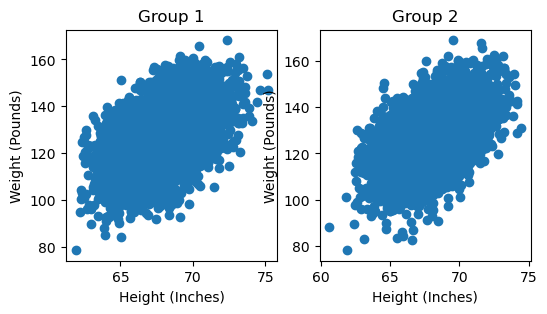

In [5]:
# your code here
group_1 = df_socr.query("GroupID == 1")
group_2 = df_socr.query("GroupID == 2")

fig, subfig = plt.subplots(nrows = 1, ncols = 2, figsize = (6,3))
subfig[0].scatter(group_1["Height(Inches)"], group_1["Weight(Pounds)"])
subfig[0].set_xlabel("Height (Inches)")
subfig[0].set_ylabel("Weight (Pounds)")
subfig[0].set_title("Group 1")

subfig[1].scatter(group_2["Height(Inches)"], group_2["Weight(Pounds)"])
subfig[1].set_xlabel("Height (Inches)")
subfig[1].set_ylabel("Weight (Pounds)")
subfig[1].set_title("Group 2")

plt.show()

<font size = "4">

**Q4** Recoding Variables

<font size = "3">

Read in the file "datasci185.csv" from the quiz_data folder, assigning it to a DataFrame. The file is a (hypothetical) dataset of students taking DataSci 185 with the columns "Student_ID", "Major", "Year", and "Grade Pct".

1. Recode the "Grade Pct" variable into a categorical variable with the values:

    - "F" if $\textrm{Grade\_Pct} < 55$
    - "D" if $55 \leq \textrm{Grade\_Pct} < 60$
    - "C" if $60 \leq \textrm{Grade\_Pct} < 75$
    - "B" if $75 \leq \textrm{Grade\_Pct} < 87$
    - "A" if $87 \leq \textrm{Grade\_Pct}$

2. Add a column to the DataFrame called "Letter_Grade" corresponding to this new categorical variable.

3. Using Python/Pandas commands, calculate and print out the proportion of "A" students in the course (# of "A" students / # of total students). 

**Note:** Unlike the examples in class, the right endpoint of the intervals/bins are **not** inclusive, but the left ones are!


In [6]:
# your code here
df_datasci = pd.read_csv("quiz_data/datasci185.csv")

def get_grade(decimal):
    if decimal > 87:
        return "A"
    if decimal > 75:
        return "B"
    if decimal > 60: 
        return "C"
    if decimal > 55:
        return "D"
    return "F"

df_datasci["Letter_Grade"] = df_datasci["Grade Pct"].apply(get_grade)
df_datasci.head()

,Student_ID,Major,Year,Grade Pct,Letter_Grade
0,419,Environmental Sciences,Senior,88.9,A
1,5381,Anthropology,Freshman,92.1,A
2,33204,Environmental Sciences,Sophomore,83.6,B
3,5034,Physics,Sophomore,99.5,A
4,90170,International Studies,Freshman,79.9,B


<font size = "4">

**Q5** Replacing variables

<font size = "3">

Read in the file "constructors.csv" from the quiz_data folder, assigning it to a DataFrame. This dataset contains information about the entities (constructors) that designs and makes the F1 racing cars.

1. In the "nationality" column, replace the values "British", "American", and "Dutch" with the strings "UK", "USA", and "Netherlands", respectively.

2. You should use the ``.replace`` method only **one time** in your solution.

In [7]:
# your code here
df_constructors = pd.read_csv("quiz_data/constructors.csv")
nationality, replacement = ["British", "American", "Dutch"], ["UK", "USA", "Netherlands"]
df_constructors["nationality"] = df_constructors["nationality"].replace(nationality, replacement)
df_constructors.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,UK,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,UK,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


<font size = "4">

**Q6** Merging

<font size = "3">

Read in the files "sprint_results.csv" and "constructors.csv" from the quiz_data folder, assigning them to two different DataFrames.

Use `pandas.merge` to create a new DataFrame called `df_merged` by combining the two DataFrames you created by reading in the data:

1. The only column they have in common is "constructorId".

2. The DataFrame `df_merged` should have 18 total columns:

    - The first 16 columns should coincide with the 16 columns of the "sprint_results" DataFrame, appearing in the same order. 

    - The last two columns should be "name" and "nationality" which are taken from the "constructors" DataFrame.

3. You only need a single call to `pd.merge` for this problem. Do not use the `.drop` method after merging the DataFrames. Only merge the required columns.

In [8]:
# your code here
df_sprint = pd.read_csv("quiz_data/sprint_results.csv")
df_constructors = pd.read_csv("quiz_data/constructors.csv")

df_constructors_sub = df_constructors[["name", "nationality"]]

df_merged = pd.merge(df_sprint, df_constructors_sub, left_index=True, right_index=True)
df_merged.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId,name,nationality
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1,McLaren,British
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1,BMW Sauber,German
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1,Williams,British
3,4,1061,844,6,16,4,4,4,4,0,17,+11.278,1549704,16,1:30.163,1,Renault,French
4,5,1061,846,1,4,6,5,5,5,0,17,+24.111,1562537,16,1:30.566,1,Toro Rosso,Italian
